# Data Visualization and KDE Homework

In this homework, you will work through several of the main ideas from the visualization lectures: matching plots to data types, creating common charts in Python, interpreting relationships carefully, and implementing a Gaussian kernel density estimator (KDE) from scratch. You will use three small datasets packaged with this assignment: a categorical pet-count table, a synthetic student-performance dataset, and a short market-index time series. Along the way, you’ll practice bar charts, pie charts, histograms, scatter plots, boxplots, line plots, heatmaps, and KDE curves.

**Datasets included with this assignment**
- `household_pets.csv`
- `student_performance.csv`
- `daily_market_index.csv`

By the end of the homework, you should be able to connect data type and dimensionality to plot choice, summarize relationships visually and numerically, and explain why visualization supports analysis but does not automatically imply causation.

## Instructions for Completing the Homework

Welcome to this visualization assignment! You will complete each section step-by-step using starter code and short written responses. Replace the parts marked `# TODO` with your own solutions. For plotting questions, make sure your figures include readable labels and titles.

**Tips:**
- Run cells sequentially because later questions depend on earlier ones.
- Keep your code clean and readable.
- When a question asks for interpretation, connect your answer to the lecture ideas on data types, dimensionality, and careful reasoning.
- Use the lecture convention when classifying exam scores by data type.

Before you submit, restart the kernel (**Kernel → Restart**) and run all cells (**Run All**) to make sure the notebook works from top to bottom.

<div class="alert alert-block alert-info">
<h3>Student Information</h3> Please provide information about yourself.<br>
<b>Name</b>: Raj Shah<br> 
<b>NetID</b>: ras637<br>
<b>Recitation #</b>: 01:198:439:05<br>
<b>Notes to Grader</b> (optional):<br>
<br><br>
<b>IMPORTANT</b>
Your work will not be graded without your initials below<br>
I certify that this lab represents my own work and I have read the RU academic integrity policies at<br>
<a href="https://www.cs.rutgers.edu/academics/undergraduate/academic-integrity-policy">https://www.cs.rutgers.edu/academics/undergraduate/academic-integrity-policy </a><br>
<b>Initials</b>: RS

## Question 1: Loading and Exploring the Datasets

Before creating any visualizations, we should understand what data we have. In this question, you will load the three datasets used throughout the assignment and inspect their basic structure. This mirrors the first step of exploratory data analysis: understand the observations, features, and context before plotting.

**Tasks:**
- Load `household_pets.csv`, `student_performance.csv`, and `daily_market_index.csv` into DataFrames named `pets_df`, `students_df`, and `market_df`.
- Display the first 5 rows of each DataFrame.
- Print the shape of each DataFrame.
- Print the data types of the columns in `students_df`.
- Compute and print the total pet count, mean midterm score, and mean final score.

**Why It Matters:** Visualization starts with knowing what each row and column represents. If you do not understand the structure of the data first, it is easy to choose an inappropriate chart or misread a pattern.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: use a clean default plotting style
plt.style.use("default")

# TODO: Load the three CSV files
pets_df    = pd.read_csv("household_pets.csv")
students_df = pd.read_csv("student_performance.csv")
market_df  = pd.read_csv("daily_market_index.csv")
market_df["date"] = pd.to_datetime(market_df["date"])

# TODO: Display the first 5 rows of each DataFrame
display(pets_df.head())
display(students_df.head())
display(market_df.head())

# TODO: Print shapes
print("pets_df shape:",     pets_df.shape)
print("students_df shape:", students_df.shape)
print("market_df shape:",   market_df.shape)

# TODO: Print the dtypes of students_df
print(students_df.dtypes)

# TODO: Compute and print a few basic summary statistics
total_pets   = pets_df["count"].sum()
mean_midterm = students_df["midterm"].mean()
mean_final   = students_df["final"].mean()

print(f"Total pet count: {total_pets}")
print(f"Mean midterm score: {mean_midterm:.2f}")
print(f"Mean final score: {mean_final:.2f}")

,pet_type,count
0,Dogs,48
1,Cats,36
2,Rabbits,14
3,Birds,10
4,Fish,22


,student_id,section,study_hours,attendance_rate,midterm,final,project_score,homework_avg
0,S001,A,5.05,0.909,77.0,87.3,70.1,58.8
1,S002,A,7.38,0.864,72.0,85.4,77.1,60.7
2,S003,A,7.66,0.950,89.9,88.1,89.9,71.6
3,S004,A,6.19,0.809,67.9,81.6,73.2,71.7
4,S005,A,6.03,0.904,84.0,95.1,76.1,69.6


,date,close
0,2026-02-02,38385.41
1,2026-02-03,38510.84
2,2026-02-04,38611.68
3,2026-02-05,38807.29
4,2026-02-06,38806.23


pets_df shape: (5, 2)
students_df shape: (96, 8)
market_df shape: (25, 2)
student_id             str
section                str
study_hours        float64
attendance_rate    float64
midterm            float64
final              float64
project_score      float64
homework_avg       float64
dtype: object
Total pet count: 130
Mean midterm score: 73.61
Mean final score: 77.98


## Question 2: Data Types and Plot Selection

One of the main ideas in lecture is that the best plot depends on the type and dimensionality of the data. In this question, you will classify several variables using the lecture categories (**nominal, ordinal, interval, ratio**) and choose appropriate visualizations for common analysis goals.

**Tasks:**
- Create a dictionary `data_types` that classifies the variables `pet_type`, `count`, `section`, `study_hours`, `midterm`, and `attendance_rate`.
- Create a dictionary `plot_choices` for the scenarios `pet_counts`, `midterm_vs_final`, `final_by_section`, and `market_over_time`.
- Create a dictionary `plot_reasons` that gives a short one-sentence reason for each plot choice.

**Why It Matters:** Good visualization is not just about making attractive charts. It depends on matching the chart to the structure of the data and the kind of question you want to answer.

**Hint:** Follow the lecture convention when classifying exam scores.

In [4]:
# TODO: Classify variables using nominal / ordinal / interval / ratio
data_types = {
    "pet_type": "nominal",
    "count": "ratio",
    "section": "nominal",
    "study_hours": "ratio",
    "midterm": "interval",
    "attendance_rate": "ratio"
}

# TODO: Choose a good plot for each scenario
plot_choices = {
    "pet_counts":       "bar chart",
    "midterm_vs_final": "scatter plot",
    "final_by_section": "box plot",
    "market_over_time": "line plot"
}

# TODO: Give a short reason for each choice
plot_reasons = {
    "pet_counts":       "A bar chart compares counts across unordered categories, making relative frequency easy to read.",
    "midterm_vs_final": "A scatter plot shows the joint distribution of two continuous variables and reveals correlation.",
    "final_by_section": "A box plot summarizes the distribution (median, spread, outliers) of a continuous variable across groups.",
    "market_over_time": "A line plot connects ordered time points, making trends and direction of change immediately visible."
}

print("Data types:")
for key, value in data_types.items():
    print(f"  {key}: {value}")

print("\nPlot choices:")
for key, value in plot_choices.items():
    print(f"  {key}: {value}")

print("\nReasons:")
for key, value in plot_reasons.items():
    print(f"  {key}: {value}")

Data types:
  pet_type: nominal
  count: ratio
  section: nominal
  study_hours: ratio
  midterm: interval
  attendance_rate: ratio

Plot choices:
  pet_counts: bar chart
  midterm_vs_final: scatter plot
  final_by_section: box plot
  market_over_time: line plot

Reasons:
  pet_counts: A bar chart compares counts across unordered categories, making relative frequency easy to read.
  midterm_vs_final: A scatter plot shows the joint distribution of two continuous variables and reveals correlation.
  final_by_section: A box plot summarizes the distribution (median, spread, outliers) of a continuous variable across groups.
  market_over_time: A line plot connects ordered time points, making trends and direction of change immediately visible.


## Question 3: Visualizing 1D Categorical Data with Bar and Pie Charts

The lectures used pet counts as a simple example of categorical data. In this question, you will create both a bar chart and a pie chart from the same table and compare what each view emphasizes.

**Tasks:**
- Compute the percentage share for each pet type and store it in `pet_share`.
- Create a bar chart of pet counts.
- Create a pie chart of pet proportions.
- Print the pet type with the largest count.

**Why It Matters:** Bar charts make category comparisons easy, while pie charts emphasize proportions of a whole. Seeing the same data in both forms helps you understand what each plot is best at communicating.

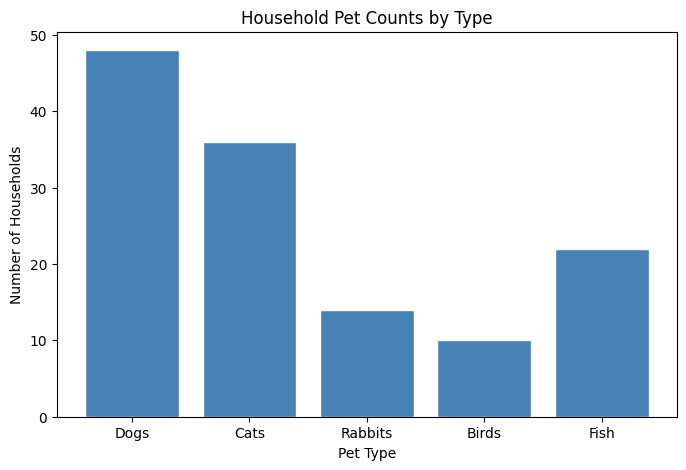

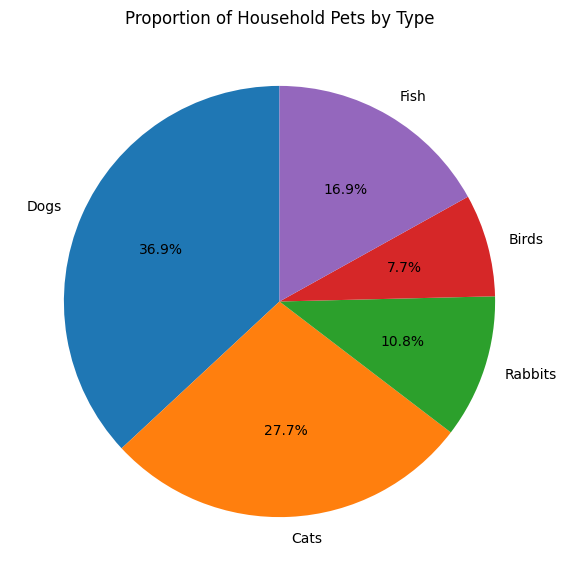

Most common pet type: Dogs


In [5]:
# TODO: Compute category shares
pet_share = pets_df["count"] / pets_df["count"].sum() * 100

# TODO: Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(pets_df["pet_type"], pets_df["count"], color="steelblue", edgecolor="white")
plt.xlabel("Pet Type")
plt.ylabel("Number of Households")
plt.title("Household Pet Counts by Type")
plt.show()

# TODO: Create a pie chart
plt.figure(figsize=(7, 7))
plt.pie(pet_share, labels=pets_df["pet_type"], autopct="%1.1f%%", startangle=90)
plt.title("Proportion of Household Pets by Type")
plt.show()

# TODO: Print the category with the largest count
top_pet = pets_df.loc[pets_df["count"].idxmax(), "pet_type"]
print(f"Most common pet type: {top_pet}")

## Question 4: Visualizing 1D Numerical Data with a Histogram

Histograms are useful for understanding the distribution of interval or ratio data. Here you will examine the distribution of final-exam scores and compute a few summary statistics to connect the visualization to numerical summaries.

**Tasks:**
- Create a histogram of `students_df["final"]` using 10 bins.
- Label the axes and title.
- Compute the mean, median, standard deviation, and interquartile range (IQR) of final scores.
- Print these summary values.

**Why It Matters:** A histogram can reveal spread, skew, clusters, and possible outliers that may not be obvious from a single average. Pairing the plot with statistics gives a more complete picture of the data.

**Hint:** Use `quantile(0.75) - quantile(0.25)` for the IQR.

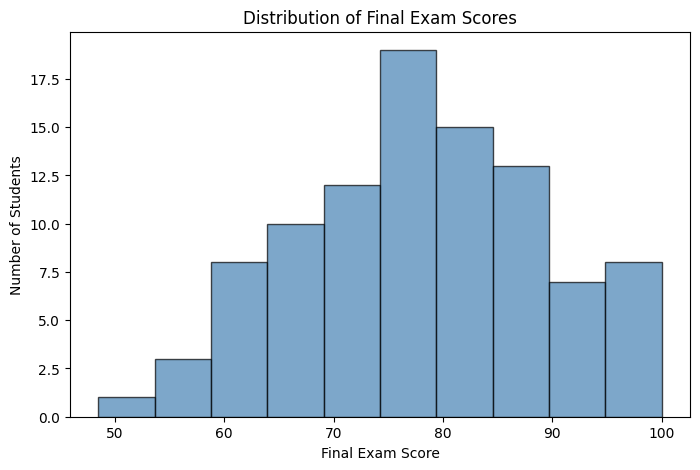

Mean: 77.98
Median: 78.25
Standard deviation: 11.17
IQR: 14.85


In [6]:
# TODO: Create histogram of final scores
plt.figure(figsize=(8, 5))
plt.hist(students_df["final"], bins=10, edgecolor="black", alpha=0.7, color="steelblue")
plt.xlabel("Final Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Exam Scores")
plt.show()

# TODO: Compute summary statistics for final scores
final_mean   = students_df["final"].mean()
final_median = students_df["final"].median()
final_std    = students_df["final"].std()
final_iqr    = students_df["final"].quantile(0.75) - students_df["final"].quantile(0.25)

print(f"Mean: {final_mean:.2f}")
print(f"Median: {final_median:.2f}")
print(f"Standard deviation: {final_std:.2f}")
print(f"IQR: {final_iqr:.2f}")

## Question 5: Scatter Plot, Correlation, and $R^2$

A scatter plot is the standard visualization for exploring the relationship between two numerical variables. In the lectures, midterm versus final performance was used as a motivating example. In this question, you will create that plot, compute Pearson correlation, and overlay a simple best-fit line.

**Tasks:**
- Create a scatter plot of `midterm` vs `final`.
- Compute the Pearson correlation coefficient `r`.
- Compute $R^2 = r^2$.
- Fit a straight line using `np.polyfit` and overlay it on the scatter plot.
- Print `r` and `R^2`.

**Why It Matters:** Scatter plots let you see patterns that a single summary statistic can miss, while correlation and $R^2$ help quantify the strength of a linear relationship.

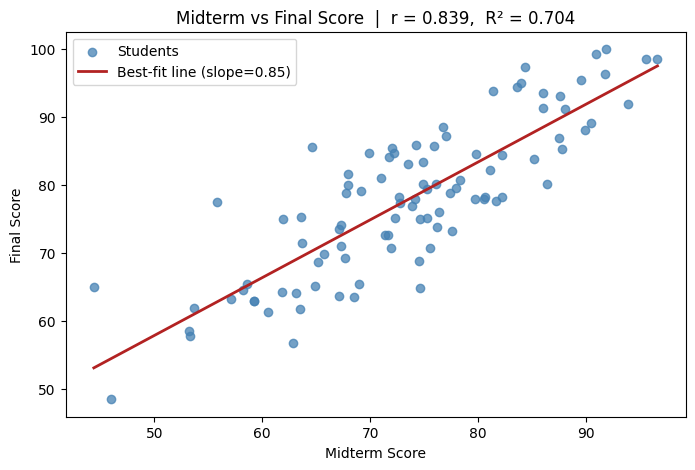

Pearson r:  0.8391
R^2:        0.7040


In [7]:
x = students_df["midterm"]
y = students_df["final"]

# TODO: Compute Pearson correlation and R^2
r         = x.corr(y)
r_squared = r ** 2

# TODO: Fit a line
slope, intercept = np.polyfit(x, y, 1)

# Scatter plot with best-fit line
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

# TODO: Create the scatter plot with best-fit line
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.75, color="steelblue", label="Students")
plt.plot(x_line, y_line, color="firebrick", linewidth=2, label=f"Best-fit line (slope={slope:.2f})")
plt.xlabel("Midterm Score")
plt.ylabel("Final Score")
plt.title(f"Midterm vs Final Score  |  r = {r:.3f},  R² = {r_squared:.3f}")
plt.legend()
plt.show()

print(f"Pearson r:  {r:.4f}")
print(f"R^2:        {r_squared:.4f}")

## Question 6: Comparing Distributions with a Boxplot

A box-and-whisker plot summarizes the five-number structure of a distribution and is useful for comparing groups. Here you will compare final-exam scores across sections.

**Tasks:**
- Compute the median final score for each section.
- Create a boxplot of final scores grouped by `section`.
- Identify which section has the highest median final score.

**Why It Matters:** A boxplot shows center, spread, and potential outliers for multiple groups at once, making it easier to compare sections than by looking at raw scores alone.

section
A    85.60
B    76.35
C    70.90
Name: final, dtype: float64


<Figure size 800x500 with 0 Axes>

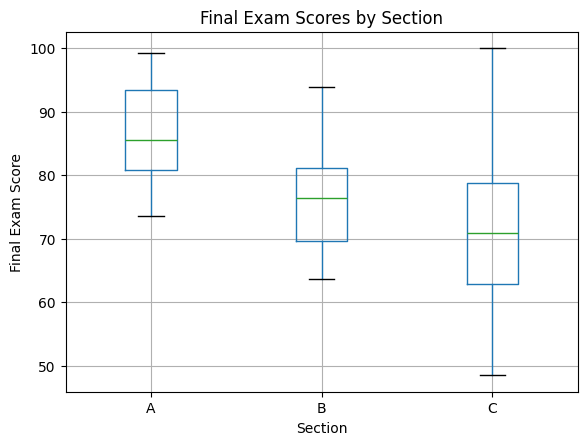

Section with highest median final score: A


In [8]:
# TODO: Compute median final score by section
section_medians = students_df.groupby("section")["final"].median()
print(section_medians)

# TODO: Create a boxplot of final scores by section
plt.figure(figsize=(8, 5))
students_df.boxplot(column="final", by="section")
plt.title("Final Exam Scores by Section")
plt.suptitle("")  # removes the automatic pandas subtitle
plt.xlabel("Section")
plt.ylabel("Final Exam Score")
plt.show()

# TODO: Identify the section with the highest median
best_section = section_medians.idxmax()
print(f"Section with highest median final score: {best_section}")

## Question 7: Time Series Visualization with a Line Plot

Line plots are appropriate when one dimension represents an ordered progression such as time. Using the market-index data, you will create a time series plot and quantify the largest one-day gain and loss.

**Tasks:**
- Convert the `date` column to datetime format.
- Create a line plot of `close` versus `date`.
- Compute one-day changes using `diff()`.
- Print the date of the largest one-day increase and the date of the largest one-day decrease.

**Why It Matters:** When time is part of the problem, the ordering of the x-axis matters. A line plot helps you see movement, volatility, and short-term trends much more naturally than an unordered chart.

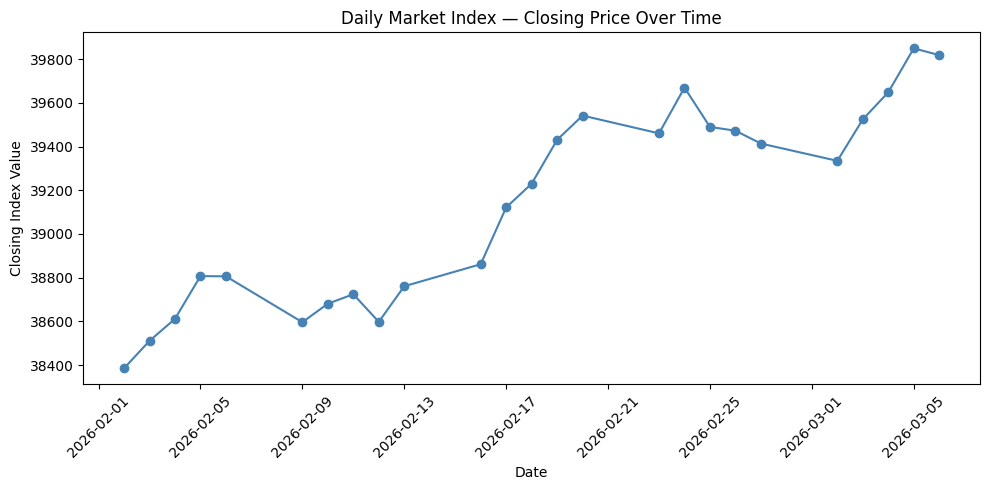

Largest one-day gain:
date            2026-02-17 00:00:00
daily_change                  260.0
Name: 11, dtype: object

Largest one-day drop:
date            2026-02-09 00:00:00
daily_change                 -210.0
Name: 5, dtype: object


In [9]:
# TODO: Convert the date column to datetime
market_df["date"] = pd.to_datetime(market_df["date"])

# TODO: Create the line plot
plt.figure(figsize=(10, 5))
plt.plot(market_df["date"], market_df["close"], marker="o", color="steelblue")
plt.xlabel("Date")
plt.ylabel("Closing Index Value")
plt.title("Daily Market Index — Closing Price Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TODO: Compute daily changes and locate largest gain / loss
market_df["daily_change"] = market_df["close"].diff()
max_gain_row = market_df.loc[market_df["daily_change"].idxmax()]
max_drop_row = market_df.loc[market_df["daily_change"].idxmin()]


print("Largest one-day gain:")
print(max_gain_row[["date", "daily_change"]])

print("\nLargest one-day drop:")
print(max_drop_row[["date", "daily_change"]])

## Question 8: Correlation Heatmap

Heatmaps can summarize many pairwise relationships at once. In this question, you will compute a correlation matrix for the numeric student variables and visualize it using a heatmap.

**Tasks:**
- Select the numeric columns `study_hours`, `attendance_rate`, `midterm`, `final`, `project_score`, and `homework_avg`.
- Compute the correlation matrix.
- Plot a heatmap with annotations.
- Identify the strongest off-diagonal relationship.

**Why It Matters:** A heatmap provides a quick overview of which numerical variables move together strongly and which do not, making it a useful summary tool during exploratory analysis.

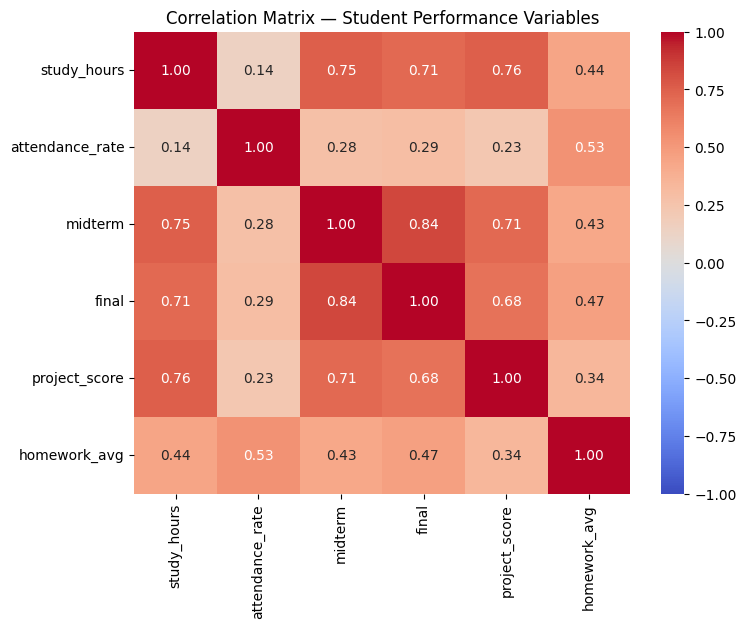

ValueError: underlying array is read-only

In [10]:
numeric_cols = ["study_hours", "attendance_rate", "midterm", "final", "project_score", "homework_avg"]

# TODO: Compute the correlation matrix
corr_matrix = students_df[numeric_cols].corr()

# TODO: Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix — Student Performance Variables")
plt.show()

# TODO: Find the strongest off-diagonal pair
abs_corr = corr_matrix.abs().copy()
np.fill_diagonal(abs_corr.values, 0)

strongest_pair  = abs_corr.stack().idxmax()
strongest_value = abs_corr.stack().max()

print(f"Strongest pair: {strongest_pair}")
print(f"Absolute correlation: {strongest_value:.4f}")

## Question 9: Implementing a Gaussian KDE from Scratch

The lecture introduced KDE as a smooth alternative to a histogram. We will use the 10-point example from class:

`[0.7, 0.8, 0.9, 2.1, 2.2, 2.8, 2.9, 3.1, 3.6, 4.8]`

Your job is to implement a Gaussian kernel and a 1D KDE estimator, then compare two bandwidth choices.

**Tasks:**
- Implement `gaussian_kernel(u) = exp(-u^2 / 2) / sqrt(2π)`.
- Implement `kde_estimate(x_grid, data, h)`.
- Plot a density histogram of the 10 values and overlay KDE curves for `h = 0.15` and `h = 0.40`.
- Estimate the density at `x = 2.5` using `h = 0.40`.

**Why It Matters:** KDE gives a smooth estimate of a distribution. The bandwidth controls the smoothness: small values preserve local bumps, while larger values smooth the curve more aggressively.

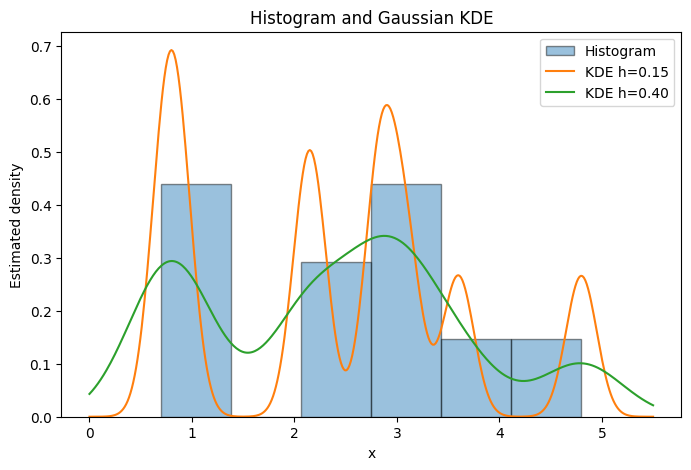

Estimated density at x=2.5 (h=0.40): 0.306256


In [ ]:
kde_points = np.array([0.7, 0.8, 0.9, 2.1, 2.2, 2.8, 2.9, 3.1, 3.6, 4.8])

# TODO: Implement the Gaussian kernel
def gaussian_kernel(u):
    return np.exp(-u**2 / 2) / np.sqrt(2 * np.pi)

# TODO: Implement the KDE estimator
def kde_estimate(x_grid, data, h):
    x_grid = np.asarray(x_grid)
    data = np.asarray(data)
    density = np.zeros_like(x_grid, dtype=float)
    for i, x in enumerate(x_grid):
        u          = (x - data) / h
        density[i] = np.sum(gaussian_kernel(u)) / (len(data) * h)
    return density

x_grid = np.linspace(0, 5.5, 400)

# TODO: Compute KDE curves for two bandwidths
density_h1 = kde_estimate(x_grid, kde_points, h=0.15)
density_h2 = kde_estimate(x_grid, kde_points, h=0.40)

# TODO: Plot histogram and KDE curves
plt.figure(figsize=(8, 5))
plt.hist(kde_points, bins=6, density=True, alpha=0.45, edgecolor="black", label="Histogram")
plt.plot(x_grid, density_h1, label="KDE h=0.15")
plt.plot(x_grid, density_h2, label="KDE h=0.40")
plt.xlabel("x")
plt.ylabel("Estimated density")
plt.title("Histogram and Gaussian KDE")
plt.legend()
plt.show()

# TODO: Estimate density at x = 2.5 using h = 0.40
density_at_2_5 = kde_estimate([2.5], kde_points, h=0.40)[0]
print(f"Estimated density at x=2.5 (h=0.40): {density_at_2_5:.6f}")

## Question 10: Interpreting Visualizations and Reflecting on Theory

To finish, answer the following questions in the markdown cell below:

- **a)** Your scatter plot may show a strong positive relationship between midterm and final scores. Explain why this does **not** prove that doing well on the midterm causes doing well on the final.
- **b)** Give one example of how a visualization can mislead a viewer, and explain one concrete fix.
- **c)** Compare a histogram and a KDE. What does the bandwidth parameter do in a KDE?

**Why It Matters:** Visualization is not only about drawing charts. It is also about making careful, honest interpretations and knowing the limits of what a graph can prove.

**Your Answers:**

a) Correlation does not mean causation. Both the midterm and final scores are
probably driven by the same underlying things, like how much a student studies
or how strong their background is. The midterm does not cause the final score,
both are just symptoms of the same habits and abilities. The scatter plot shows
they move together, but it cannot tell us why.

b) A common trick is cutting the y-axis so it does not start at zero. Imagine
a bar chart where the y-axis starts at 950 instead of 0. A difference between
960 and 980 will look massive even though it is tiny. The fix is to start the
y-axis at zero, or at least label clearly that it is cut so the reader knows.

c) A histogram chops the data into bins and counts values in each bin. The
problem is the shape changes a lot depending on how many bins you pick. KDE
instead places a small smooth bump over each data point and adds them all up
into one curve. The bandwidth controls how wide those bumps are. Small bandwidth
means narrow bumps, so the curve is wiggly and detailed. Large bandwidth means
wide bumps, so the curve is smoother but hides some detail. Picking the right
bandwidth is the main decision in KDE, same as picking bin count in a histogram.